In [ ]:
!ls

In [2]:
dpi = 300
# default
width = 6.4
height = 4.8
tw = 8
rot = 45


In [3]:
get_results(1024)

NameError: name 'get_results' is not defined

In [4]:
import matplotlib.pyplot as plt
import os

In [5]:
counts = {}
for file in os.listdir('.'):
    if file.endswith('.log'):
        with open(file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                setting = ",".join(line.split(",")[1:]).split(", Dev")[0]
                parts = line.strip().split("Cache Length: ")
                parts = parts[1].split(",")
                cache_len = int(parts[0])
                if cache_len == 1024:
                    if setting not in counts:
                        counts[setting] = 0
                    counts[setting] += 1
counts

{' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.1412699385250087\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.15213528582807426\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.16285766803504687\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14380246308436984\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.1422502706125033\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14584482159998366\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14637583481404326\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14071850172579295\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14649837632498008\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14345526213671547\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.1607336151788085\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.13971774605314216\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.1398811347343913\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test 

In [5]:
counts

{' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.1412699385250087\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.15213528582807426\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.16285766803504687\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14380246308436984\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.1422502706125033\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14584482159998366\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14637583481404326\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14071850172579295\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14649837632498008\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.14345526213671547\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.1607336151788085\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.13971774605314216\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test WER: 0.1398811347343913\n': 1,
 ' alpha: 0.42, beta: 1.95, p: 2.96, Test 

In [6]:
def get_results(seq_len):
    paths = [f"./n_seq_sched_{seq_len}_rp_{rp}_tlm_beam_grid_search.log" for rp in [1, 2, 3]]
    paths = [p for p in paths if os.path.exists(p)]
    results = {}
   
    for path in paths:
        with open(path, "r") as f:
            lines = f.readlines()
            for line in lines:
                assert "WER" in line
                parts = line.strip().split("Test WER: ")
                wer = float(parts[1])
                parts = line.strip().split("Cache Length: ")
                parts = parts[1].split(",")
                cache_len = int(parts[0])
                if cache_len not in results:
                    results[cache_len] = []
                results[cache_len].append(wer)
    for k, v in results.items():
        print(len(v))
        if len(v) != 3:
            print(f"Warning: Cache Length {k} has {len(v)} results, expected 3.")
    avg_results = {k: sum(v)/len(v) for k, v in results.items()}
    return avg_results

def get_pdecrease(results):
    sorted_keys = sorted(results.keys())
    print(sorted_keys)
    p_decrease = {}
    for i in range(1, len(sorted_keys)):
        min_val = results[sorted_keys[0]]
        curr_val = results[sorted_keys[i]]
        p_decrease[sorted_keys[i]] = ((min_val - curr_val) / min_val) * 100
        
    return p_decrease

In [7]:
get_results(32768*2)

3
3
3
3
3
3


{64: 0.1445240964265534,
 128: 0.14369353729687043,
 256: 0.14265193445390736,
 512: 0.14189626180313025,
 1024: 0.14182818318594315,
 2048: 0.1412222834929777}

3
3
3
3
3
3
[64, 128, 256, 512, 1024, 2048]
3
3
3
3
3
3
[64, 128, 256, 512, 1024, 2048]
3
3
3
3
3
3
[64, 128, 256, 512, 1024, 2048]
3
3
3
3
3
3
[64, 128, 256, 512, 1024, 2048]
3
3
3
3
3
3
[64, 128, 256, 512, 1024, 2048]
3
3
3
3
3
3
[64, 128, 256, 512, 1024, 2048]
3
3
3
3
3
3
[64, 128, 256, 512, 1024, 2048]
3
3
3
3
3
3
[64, 128, 256, 512, 1024, 2048]
3
3
3
3
3
3
[64, 128, 256, 512, 1024, 2048]
3
3
3
3
3
3
[64, 128, 256, 512, 1024, 2048]


/tmp/ipykernel_10124/1043361421.py:20: MatplotlibDeprecationWarning: The 'basex' parameter of __init__() has been renamed 'base' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.set_xscale('log', basex=2)


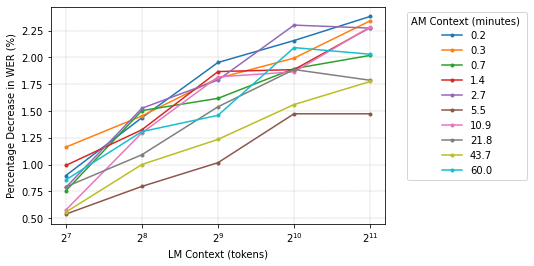

In [7]:
LM_seq_lens = [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 360000]
for seq_len in LM_seq_lens:
    results = get_results(seq_len)
    results = get_pdecrease(results)
    # log scale x axis
    

    plt.plot(list(results.keys()), list(results.values()), label=f"{round(seq_len/100/60,1)}", marker='o', markersize=3)
    ax = plt.gca()
    ax.grid(True, which='both', linestyle='--', linewidth=0.4)

import matplotlib
plt.xlabel('LM Context (tokens)')
plt.ylabel('Percentage Decrease in WER (%)')

# shift legend outside plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='AM Context (minutes) ')

ax=plt.gca()
ax.set_xscale('log', basex=2)
# ax.set_xticks([el/100/60 for el in sorted(LM_seq_lens)]) 
# ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.grid(True, which='both', linestyle='--', linewidth=0.4)

# plt.legend(loc='upper right')

In [8]:
import pandas as pd

def get_data(df, dataset='earnings22', split='test', return_all=False, average_duplicates=False):
    seq_lens = df.loc[df['dataset'] == dataset].loc[df['split'] == split]['seq_len'].unique()
    print(seq_lens)

    out_data = {}
    for seq_len in seq_lens:
        sset = df.loc[df['dataset'] == dataset].loc[df['split'] == split].loc[df['seq_len'] == seq_len]
        if average_duplicates:
            # find examples with the same checkpoint and average the wer field on them and remove duplicates
            sset = sset.groupby('checkpoint').agg({'wer': 'mean'}).reset_index()
            
        if not return_all:
            out_data[seq_len] = {'wer': sset['wer'].mean()*100, 'std': sset['wer'].std()*100}
        else:
            out_data[seq_len] = [el*100 for el in sset['wer'].tolist()]
        if len(sset) != 3:
            print(f'Sequence length {seq_len} has {len(sset)} results')
    return out_data

rb1p5M_csv = pd.read_csv('../../../results/evals_rb_post_windowed_attn.csv')

In [111]:
get_data(rb1p5M_csv)

[  1024   2048   4096   8192  16384  32768  65536 131072 262144 360000]


{1024: {'wer': 20.699303555746173, 'std': 0.23220996601253943},
 2048: {'wer': 19.650892851064405, 'std': 0.15557267447270903},
 4096: {'wer': 19.273737311847718, 'std': 0.3664198366944614},
 8192: {'wer': 18.654902681616726, 'std': 0.054954247276817074},
 16384: {'wer': 18.42615852786798, 'std': 0.21878989017571795},
 32768: {'wer': 18.3070209477905, 'std': 0.049874266711305654},
 65536: {'wer': 18.24098468911899, 'std': 0.012310752554663752},
 131072: {'wer': 18.05581085037, 'std': 0.3668142607448155},
 262144: {'wer': 18.08576544193234, 'std': 0.1937587292643537},
 360000: {'wer': 18.01632525240147, 'std': 0.07052300724264236}}

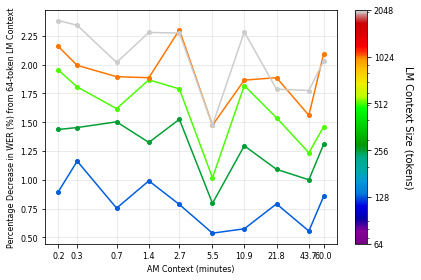

In [101]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import numpy as np

def get_all_data(am_seq_lens):
    data_by_lm = {}
    for seq_len in am_seq_lens:
        paths = [f"./n_seq_sched_{seq_len}_rp_{rp}_tlm_beam_grid_search.log" for rp in [1, 2, 3]]
        paths = [p for p in paths if os.path.exists(p)]
        temp_results = {}
        for path in paths:
            with open(path, "r") as f:
                for line in f:
                    if "Test WER: " in line:
                        parts = line.strip().split("Test WER: ")
                        wer = float(parts[1])
                        parts = line.strip().split("Cache Length: ")
                        cache_len = int(parts[1].split(",")[0])
                        if cache_len not in temp_results: temp_results[cache_len] = []
                        temp_results[cache_len].append(wer)
        
        for cache_len, wers in temp_results.items():
            if cache_len not in data_by_lm: data_by_lm[cache_len] = {}
            data_by_lm[cache_len][seq_len] = sum(wers) / len(wers)
    return data_by_lm

# --- Main Execution ---

am_seq_lens = [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 360000]
data_by_lm = get_all_data(am_seq_lens)

ax = plt.gca()
sorted_lm_contexts = sorted(data_by_lm.keys())

# --- 1. Setup Color Mapping ---
cmap_base = cm.nipy_spectral
cmap = colors.LinearSegmentedColormap.from_list(
    'trunc_viridis', cmap_base(np.linspace(0.05, 1, 256))
)

# Keep LogNorm because your data is exponential (64 -> 128 -> 256).
# If we used linear, 64 and 128 would be identical colors compared to 32000.
# LogNorm makes them distinct.
norm = colors.LogNorm(vmin=min(sorted_lm_contexts), vmax=max(sorted_lm_contexts))

# --- 2. Plotting ---
for lm_ctx in sorted_lm_contexts[1:]:
    am_data = data_by_lm[lm_ctx]
    sorted_am_keys = sorted(am_data.keys())
    
    if not sorted_am_keys: continue

    x_values = []
    y_values = []
    
    for am_seq in sorted_am_keys:
        curr_wer = am_data[am_seq]
        if 64 in data_by_lm and am_seq in data_by_lm[64]:
            baseline_wer = data_by_lm[64][am_seq]
            p_decrease = ((baseline_wer - curr_wer) / baseline_wer) * 100
            
            x_values.append(round(am_seq / 100 / 60, 1))
            y_values.append(p_decrease)
    
    line_color = cmap(norm(lm_ctx))
    ax.plot(x_values, y_values, color=line_color, marker='o', markersize=4)

# --- 3. Add Colorbar ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(np.array(sorted_lm_contexts)) 

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('LM Context Size (tokens)', rotation=270, labelpad=20)

# --- FIX: Force the ticks to be exactly your LM Contexts ---
# This overrides the default "powers of 10" behavior
cbar.set_ticks(sorted_lm_contexts)
cbar.set_ticklabels([str(x) for x in sorted_lm_contexts])

# --- 4. Styling ---
ax.set_xlabel('AM Context (minutes)', fontsize=tw)
ax.set_ylabel('Percentage Decrease in WER (%) from 64-token LM Context', fontsize=tw)
ax.grid(True, axis='both', alpha=0.3)

ax.set_xscale('log', base=2)
ax.set_xticks([round(el/100/60, 1) for el in sorted(am_seq_lens)]) 
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

plt.tight_layout()
plt.savefig('wer_vs_am_context_vs_lm_64.pdf', bbox_inches='tight')
plt.show()

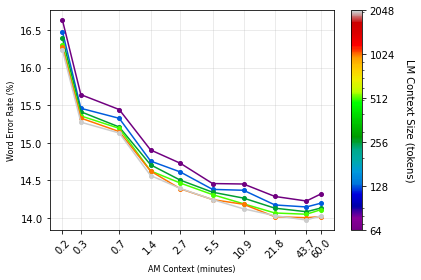

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import numpy as np

def get_all_data(am_seq_lens):
    """
    Parses all log files and pivots data to be distinct by LM Context.
    Returns: dict { lm_context: { am_context: wer } }
    """
    data_by_lm = {}

    for seq_len in am_seq_lens:
        paths = [f"./n_seq_sched_{seq_len}_rp_{rp}_tlm_beam_grid_search.log" for rp in [1, 2, 3]]
        paths = [p for p in paths if os.path.exists(p)]
        
        temp_results = {}
       
        for path in paths:
            with open(path, "r") as f:
                lines = f.readlines()
                for line in lines:
                    if "Test WER: " not in line:
                        continue
                        
                    parts = line.strip().split("Test WER: ")
                    wer = float(parts[1])
                    
                    parts = line.strip().split("Cache Length: ")
                    parts = parts[1].split(",")
                    cache_len = int(parts[0])
                    
                    if cache_len not in temp_results:
                        temp_results[cache_len] = []
                    temp_results[cache_len].append(wer)
        
        for cache_len, wers in temp_results.items():
            avg_wer = sum(wers) / len(wers)
            if cache_len not in data_by_lm:
                data_by_lm[cache_len] = {}
            data_by_lm[cache_len][seq_len] = avg_wer
            
    return data_by_lm

# --- Main Execution ---

am_seq_lens = [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 360000]
data_by_lm = get_all_data(am_seq_lens)

ax=plt.gca()

sorted_lm_contexts = sorted(data_by_lm.keys())

# --- 1. Setup Color Mapping ---
cmap_base = cm.nipy_spectral
cmap = colors.LinearSegmentedColormap.from_list(
    'trunc_viridis', cmap_base(np.linspace(0.05, 1, 256))
)

# Use LogNorm for even color spacing across powers of 2 (so 64 and 128 look distinct)
norm = colors.LogNorm(vmin=min(sorted_lm_contexts), vmax=max(sorted_lm_contexts))

# --- 2. Plotting ---
for lm_ctx in sorted_lm_contexts:
    am_data = data_by_lm[lm_ctx]
    sorted_am_keys = sorted(am_data.keys())
    
    if not sorted_am_keys:
        continue

    x_values = []
    y_values = []
    
    for i in range(0, len(sorted_am_keys)):
        am_seq = sorted_am_keys[i]
        curr_wer = am_data[am_seq]
        
        # X Axis: AM Context in minutes
        x_val = round(am_seq / 100 / 60, 1)
        
        x_values.append(x_val)
        y_values.append(curr_wer * 100) # Convert fraction to percentage
        
    # Get color from map based on LM Context size
    line_color = cmap(norm(lm_ctx))
    
    # Plot line
    plt.plot(x_values, y_values, color=line_color, marker='o', markersize=4)

# --- 3. Add Colorbar ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(np.array(sorted_lm_contexts)) 

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('LM Context Size (tokens)', rotation=270, labelpad=20)

# Force ticks to be exactly your LM Contexts (original scale)
cbar.set_ticks(sorted_lm_contexts)
cbar.set_ticklabels([str(x) for x in sorted_lm_contexts])

# --- 4. Styling ---
ax.set_xlabel('AM Context (minutes)',fontsize=tw)
ax.set_ylabel('Word Error Rate (%)',fontsize=tw)

ax.set_xscale('log', base=2)
ax.set_xticks([round(el/100/60, 1) for el in sorted(am_seq_lens)]) 
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.grid(True, axis='both', alpha=0.3)
plt.rc('xtick', labelsize=tw)
plt.xticks(rotation=rot)
plt.rc('ytick', labelsize=tw)


plt.tight_layout()
plt.savefig('wer_vs_am_context.pdf', bbox_inches='tight')
plt.show()

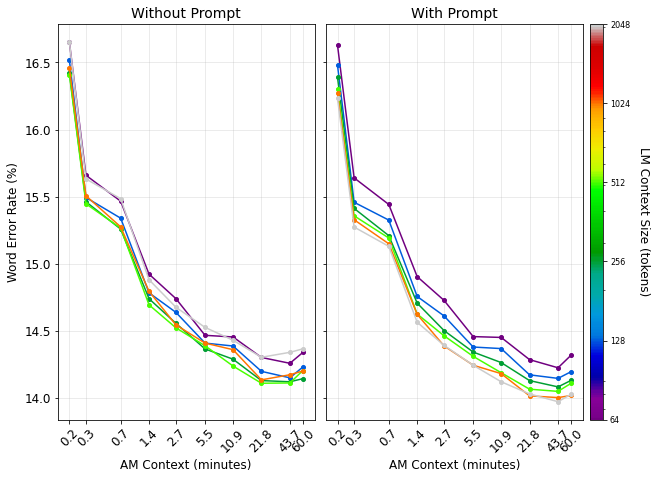

In [32]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import numpy as np

# --- Configuration for Style ---
tw = 12   
rot = 45  

def get_all_data(am_seq_lens, base_path="./"):
    """
    Parses all log files and pivots data to be distinct by LM Context.
    Returns: dict { lm_context: { am_context: wer } }
    """
    data_by_lm = {}

    for seq_len in am_seq_lens:
        paths = [f"{base_path}n_seq_sched_{seq_len}_rp_{rp}_tlm_beam_grid_search.log" for rp in [1, 2, 3]]
        paths = [p for p in paths if os.path.exists(p)]
        
        temp_results = {}
       
        for path in paths:
            with open(path, "r") as f:
                lines = f.readlines()
                for line in lines:
                    if "Test WER: " not in line:
                        continue
                        
                    parts = line.strip().split("Test WER: ")
                    wer = float(parts[1])
                    
                    parts = line.strip().split("Cache Length: ")
                    parts = parts[1].split(",")
                    cache_len = int(parts[0])
                    
                    if cache_len not in temp_results:
                        temp_results[cache_len] = []
                    temp_results[cache_len].append(wer)
        
        for cache_len, wers in temp_results.items():
            avg_wer = sum(wers) / len(wers)
            if cache_len not in data_by_lm:
                data_by_lm[cache_len] = {}
            data_by_lm[cache_len][seq_len] = avg_wer
            
    return data_by_lm

# --- Main Execution ---

am_seq_lens = [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 360000]

data_1 = get_all_data(am_seq_lens, base_path="../beam_search_thesis_constant_lm_params_no_init_cache/")
data_2 = get_all_data(am_seq_lens, base_path="./")

# --- FIX 1: Use constrained_layout=True instead of tight_layout ---
# This automatically adjusts widths to fit the colorbar nicely
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6.5), sharey=True, constrained_layout=True, gridspec_kw={'wspace': 0.01})

# Setup Color Mapping
all_lm_contexts = set(data_1.keys()).union(set(data_2.keys()))
sorted_all_contexts = sorted(list(all_lm_contexts))

cmap_base = cm.nipy_spectral
cmap = colors.LinearSegmentedColormap.from_list(
    'trunc_viridis', cmap_base(np.linspace(0.05, 1, 256))
)

if sorted_all_contexts:
    vmin = min(sorted_all_contexts)
    vmax = max(sorted_all_contexts)
else:
    vmin, vmax = 1, 100 

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# Helper Function
def plot_data_on_axis(ax, data, title, is_leftmost=False):
    sorted_lm = sorted(data.keys())
    
    for lm_ctx in sorted_lm:
        am_data = data[lm_ctx]
        sorted_am_keys = sorted(am_data.keys())
        
        if not sorted_am_keys:
            continue

        x_values = []
        y_values = []
        
        for i in range(len(sorted_am_keys)):
            am_seq = sorted_am_keys[i]
            curr_wer = am_data[am_seq]
            x_val = round(am_seq / 100 / 60, 1)
            x_values.append(x_val)
            y_values.append(curr_wer * 100) 
            
        line_color = cmap(norm(lm_ctx))
        ax.plot(x_values, y_values, color=line_color, marker='o', markersize=4)

    ax.set_title(title, fontsize=tw+2)
    ax.set_xlabel('AM Context (minutes)', fontsize=tw)
    
    if is_leftmost:
        ax.set_ylabel('Word Error Rate (%)', fontsize=tw)
    
    ax.set_xscale('log', base=2)
    tick_locs = [round(el/100/60, 1) for el in sorted(am_seq_lens)]
    ax.set_xticks(tick_locs)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    
    ax.grid(True, axis='both', alpha=0.3)
    ax.tick_params(axis='x', labelsize=tw, rotation=rot)
    ax.tick_params(axis='y', labelsize=tw)

# Plot
plot_data_on_axis(ax1, data_1, title="Without Prompt", is_leftmost=True)
plot_data_on_axis(ax2, data_2, title="With Prompt", is_leftmost=False)

# --- FIX 2: Colorbar attached to list of axes ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(np.array(sorted_all_contexts)) 

# 'fraction' controls thickness relative to plot, 'aspect' controls slenderness
cbar = fig.colorbar(sm, ax=[ax1, ax2], fraction=0.05, aspect=30, pad=0.01)
cbar.set_label('LM Context Size (tokens)', rotation=270, labelpad=20, fontsize=tw)

cbar.set_ticks(sorted_all_contexts)
cbar.set_ticklabels([str(x) for x in sorted_all_contexts])

# Do NOT use plt.tight_layout() here, constrained_layout handles it.
plt.savefig('combined_wer_plot_with_prompt_comparison.pdf', bbox_inches='tight')
plt.show()

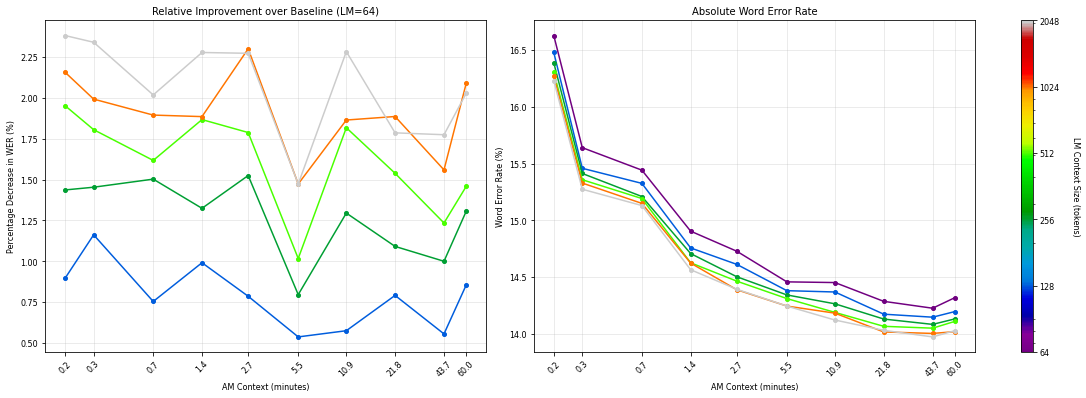

In [99]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import numpy as np



def get_all_data(am_seq_lens):
    data_by_lm = {}
    for seq_len in am_seq_lens:
        paths = [f"./n_seq_sched_{seq_len}_rp_{rp}_tlm_beam_grid_search.log" for rp in [1, 2, 3]]
        paths = [p for p in paths if os.path.exists(p)]
        
        temp_results = {}
        for path in paths:
            with open(path, "r") as f:
                for line in f:
                    if "Test WER: " in line:
                        parts = line.strip().split("Test WER: ")
                        wer = float(parts[1])
                        parts = line.strip().split("Cache Length: ")
                        cache_len = int(parts[1].split(",")[0])
                        if cache_len not in temp_results: temp_results[cache_len] = []
                        temp_results[cache_len].append(wer)
        
        for cache_len, wers in temp_results.items():
            if cache_len not in data_by_lm: data_by_lm[cache_len] = {}
            data_by_lm[cache_len][seq_len] = sum(wers) / len(wers)
    return data_by_lm

# --- Main Execution ---

am_seq_lens = [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 360000]
data_by_lm = get_all_data(am_seq_lens)
sorted_lm_contexts = sorted(data_by_lm.keys())

# --- FIX: Match exact figure size and grid from your other plot ---
fig = plt.figure(figsize=(15, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1])

# Create only the axes we need (Top Row)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# (We leave the bottom row empty so the scaling matches your other 4-panel figures)

# --- Setup Shared Color Mapping ---
cmap_base = cm.nipy_spectral
cmap = colors.LinearSegmentedColormap.from_list(
    'trunc_nipy', cmap_base(np.linspace(0.05, 1, 256))
)
norm = colors.LogNorm(vmin=min(sorted_lm_contexts), vmax=max(sorted_lm_contexts))

# ==========================================
# PLOT 1: Relative Decrease (Top Left)
# ==========================================
for lm_ctx in sorted_lm_contexts[1:]:
    am_data = data_by_lm[lm_ctx]
    sorted_am_keys = sorted(am_data.keys())
    if not sorted_am_keys: continue

    x_values = []
    y_values = []
    
    for am_seq in sorted_am_keys:
        curr_wer = am_data[am_seq]
        if 64 in data_by_lm and am_seq in data_by_lm[64]:
            baseline_wer = data_by_lm[64][am_seq]
            p_decrease = ((baseline_wer - curr_wer) / baseline_wer) * 100
            x_values.append(round(am_seq / 100 / 60, 1))
            y_values.append(p_decrease)
            
    line_color = cmap(norm(lm_ctx))
    ax1.plot(x_values, y_values, color=line_color, marker='o', markersize=4)

ax1.set_title("Relative Improvement over Baseline (LM=64)", fontsize=tw+2)
ax1.set_ylabel('Percentage Decrease in WER (%)', fontsize=tw)

# ==========================================
# PLOT 2: Absolute WER (Top Right)
# ==========================================
for lm_ctx in sorted_lm_contexts:
    am_data = data_by_lm[lm_ctx]
    sorted_am_keys = sorted(am_data.keys())
    if not sorted_am_keys: continue

    x_values = []
    y_values = []
    
    for am_seq in sorted_am_keys:
        curr_wer = am_data[am_seq]
        x_values.append(round(am_seq / 100 / 60, 1))
        y_values.append(curr_wer * 100)
        
    line_color = cmap(norm(lm_ctx))
    ax2.plot(x_values, y_values, color=line_color, marker='o', markersize=4)

ax2.set_title("Absolute Word Error Rate", fontsize=tw+2)
ax2.set_ylabel('Word Error Rate (%)', fontsize=tw)

# ==========================================
# Shared Styling & Colorbar
# ==========================================

for ax in [ax1, ax2]:
    ax.set_xlabel('AM Context (minutes)', fontsize=tw)
    ax.set_xscale('log', base=2)
    ax.set_xticks([round(el/100/60, 1) for el in sorted(am_seq_lens)]) 
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.grid(True, axis='both', alpha=0.3)
    ax.tick_params(axis='x', rotation=rot, labelsize=tw)
    ax.tick_params(axis='y', labelsize=tw)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(np.array(sorted_lm_contexts))

# Attach colorbar to the figure (referencing the top row axes)
cbar = fig.colorbar(sm, ax=[ax1, ax2], location='right', aspect=30)
cbar.set_label('LM Context Size (tokens)', rotation=270, labelpad=20, fontsize=tw)
cbar.set_ticks(sorted_lm_contexts)
cbar.set_ticklabels([str(x) for x in sorted_lm_contexts])

plt.savefig('combined_wer_analysis_large.pdf', bbox_inches='tight')
plt.show()